# Pesquisa de Satisfação do SIPEP — Análise dos Dados

**Universidade Federal de Goiás (UFG) — Projeto SIMAPES**

Este notebook apresenta a análise dos dados coletados na pesquisa de satisfação sobre o **SIPEP** (Sistema de Planejamento Estratégico e de Projetos), aplicada a servidores da UFG.

## Sobre a pesquisa

- **Temas investigados:** perfil dos usuários, frequência de uso, nível de conhecimento, satisfação geral, usabilidade da interface, sugestões de melhoria por módulo, necessidade de capacitação e unidade acadêmica. ## Colocar na sequencia do grafico.

- **Instrumento:** Formulário eletrônico com 17 perguntas (objetivas e abertas)
- ** Periodo de coleta**: DD/MM/AAAA - DD/MM/AAAA
- **Respondentes:** 190
  - **180** já utilizaram o sistema
  - **10** não utilizaram o sistema
- **Críterios de inclusão da amostra**: Foram incluidos apenas os respondentes que utilizaram o sistema (N=180).



In [44]:
#@title ⚙️ Configuração e carregamento dos dados { display-mode: "form" }
# Importações e carregamento dos dados
# (Todos os dados são carregados aqui uma única vez e reutilizados nas seções seguintes)

import os
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
import textwrap

# Detectar se está rodando no Google Colab
try:
    from google.colab import drive
    EM_COLAB = True
except ImportError:
    EM_COLAB = False

if EM_COLAB:
    # Conectar ao Google Drive se estiver no Colab
    drive.mount("/content/drive")
    # CAMINHO original estava apontando para o próprio notebook, não para o Excel.
    # Corrigido para o nome do arquivo Excel indicado no 'else' block.
    CAMINHO = "/content/drive/MyDrive/[Anotações]/[Projeto de pesquisa UFG] Simapes/[Negocio] Sipep/Banco_Dados_Pesquisa_Satisfacao_Sipep.xlsx"
else:
    # Caminho local (mesma pasta do notebook)
    CAMINHO = "Banco_Dados_Pesquisa_Satisfacao_Sipep.xlsx"

if not os.path.exists(CAMINHO):
    raise FileNotFoundError(f"Arquivo de dados não encontrado no caminho: {CAMINHO}")

# --- Grupo principal: usuários ativos (N=180) ---
_bruto_180 = pd.read_excel(CAMINHO, sheet_name='N180_Usao')
df = _bruto_180[
    (_bruto_180['Incluído na amostra'] == 'Sim') &
    (_bruto_180['5- Há quanto tempo você utiliza o Sipep?'] != 'Nunca utilizei')
].copy()

# --- Grupo de não-usuários (N=10) ---
_bruto_10 = pd.read_excel(CAMINHO, sheet_name='N10_Nunca_usou')
df_nunca = _bruto_10[
    (_bruto_10['Incluído na amostra'] == 'Sim') &
    (_bruto_10['5- Há quanto tempo você utiliza o Sipep?'] == 'Nunca utilizei')
].copy()

# Nomes abreviados das colunas mais usadas (para facilitar a leitura do código)
COL = {
    'vinculo':       '1- Qual seu vínculo com a UFG?',
    'conhecimento':  '3- Como você classifica seu grau de conhecimento sobre o SIPEP? ',
    'frequencia':    '4- Com que frequência você acessa o Sipep?',
    'tempo':         '5- Há quanto tempo você utiliza o Sipep?',
    'uso':           '6- Você utilizou o Sipep para:',
    'melhoria':      '7- Quais opções poderiam contribuir para aumentar a sua frequência de uso do Sipep? ',
    'navegacao':     '8- A navegação no sistema é clara e intuitiva.',
    'satisfacao':    '14- O quanto você está satisfeito com o Sipep?',
    'capacitacao':   '17A- Você tem necessidade de capacitação relacionado a algum módulo do Sipep?',
    'cap_quais':     '17B - Quais?',
    'plano_acao':    '9- O que poderia ser melhorado no Sipep em relação ao plano de ação?',
    'projetos':      '10- O que poderia ser melhorado no Sipep em relação à gestão de projetos?',
    'planej':        '11- O que poderia ser melhorado no Sipep em relação ao planejamento estratégico?',
    'riscos':        '12- O que poderia ser melhorado no Sipep em relação à gestão de riscos?',
    'pgd':           '13- O que poderia ser melhorado no Sipep em relação ao Programa de Gestão e Desempenho - PGD?',
    'sugestoes':     '15- Há algo mais que você gostaria de sugerir sobre o sistema?',
}

# --- Ordenações canônicas das escalas (centralizadas aqui; antes eram redefinidas em cada célula) ---
ORDEM_CONH  = ['Muito alto', 'Alto', 'Moderado', 'Baixo', 'Muito baixo']
ORDEM_TEMPO = ['Menos de 6 meses', 'De 6 meses a menos de 1 ano',
               'De 1 ano a menos de 2 anos', 'De 2 anos a menos de 4 anos', '4 anos ou mais']
ORDEM_FREQ  = ['Diariamente', 'Semanalmente', 'Mensalmente', 'Raramente']
ORDEM_NAV   = ['Concordo totalmente', 'Concordo', 'Não concordo nem discordo',
               'Discordo', 'Discordo totalmente']
ORDEM_SAT   = ['Muito satisfeito', 'Satisfeito', 'Indiferente',
               'Insatisfeito', 'Muito insatisfeito']

# --- Escalas Likert convertidas para número (1 a 5), usadas em médias e testes estatísticos ---
MAPA_SAT = {'Muito insatisfeito': 1, 'Insatisfeito': 2, 'Indiferente': 3,
            'Satisfeito': 4, 'Muito satisfeito': 5}
MAPA_NAV = {'Discordo totalmente': 1, 'Discordo': 2, 'Não concordo nem discordo': 3,
            'Concordo': 4, 'Concordo totalmente': 5}

# Configurações visuais padrão
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

# Cores consistentes para todos os gráficos
CORES = {
    'azul':      '#1a73e8',
    'vermelho':  '#ea4335',
    'amarelo':   '#fbbc05',
    'verde':     '#34a853',
    'cinza':     '#5f6368',
    'roxo':      '#8a3af4',
    'texto':     '#202124',
    'subtexto':  '#5f6368',
    'grade':     '#dadce0',
}

N = len(df)
N10 = len(df_nunca)


# --- Funções auxiliares para geração de gráficos ---

def contagem_valida(serie, ordem=None):
    """Conta as categorias de uma coluna IGNORANDO respostas em branco (NaN).

    Devolve (contagem, base_valida), onde base_valida é o nº de pessoas que de fato
    responderam à pergunta. Use essa base para calcular percentuais — assim uma
    pergunta com muitos brancos (ex.: capacitação, com 101 não respondidas) não fica
    com o indicador subestimado por dividir pelo total da amostra.
    """
    s = serie.dropna()
    base = len(s)
    contagem = s.value_counts()
    if ordem is not None:
        contagem = contagem.reindex(ordem).fillna(0)
    return contagem, base

def rotular_barras(ax, total):
    for bar in ax.patches:
        w = bar.get_width()
        if w > 0:
            pct = w / total * 100 if total else 0
            ax.text(w + 0.5, bar.get_y() + bar.get_height()/2,
                    f" {int(w)}  ({pct:.1f}%)",
                    va='center', fontweight='bold', color=CORES['texto'], fontsize=11)

def limpar_eixo(ax, titulo):
    ax.set_title(titulo, fontsize=13, fontweight='bold', pad=15, color=CORES['texto'], loc='left')
    ax.set_xticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_axisbelow(True)
    ax.grid(axis='x', linestyle='-', alpha=0.15, color=CORES['grade'])
    sns.despine(ax=ax, left=False, bottom=True, right=True, top=True)

print(f"Dados carregados com sucesso.")
print(f"  → Usuários ativos: {N} respondentes")
print(f"  → Nunca utilizaram: {N10} respondentes")
print(f"  → Total da amostra: {N + N10} respondentes")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dados carregados com sucesso.
  → Usuários ativos: 180 respondentes
  → Nunca utilizaram: 10 respondentes
  → Total da amostra: 190 respondentes


In [45]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## 1. Perfil dos Respondentes (N=180)

Esta seção mostra quem são os usuários do SIPEP: o tipo de vínculo com a UFG, o nível de conhecimento que declaram ter sobre o sistema, há quanto tempo o utilizam e com que frequência acessam.

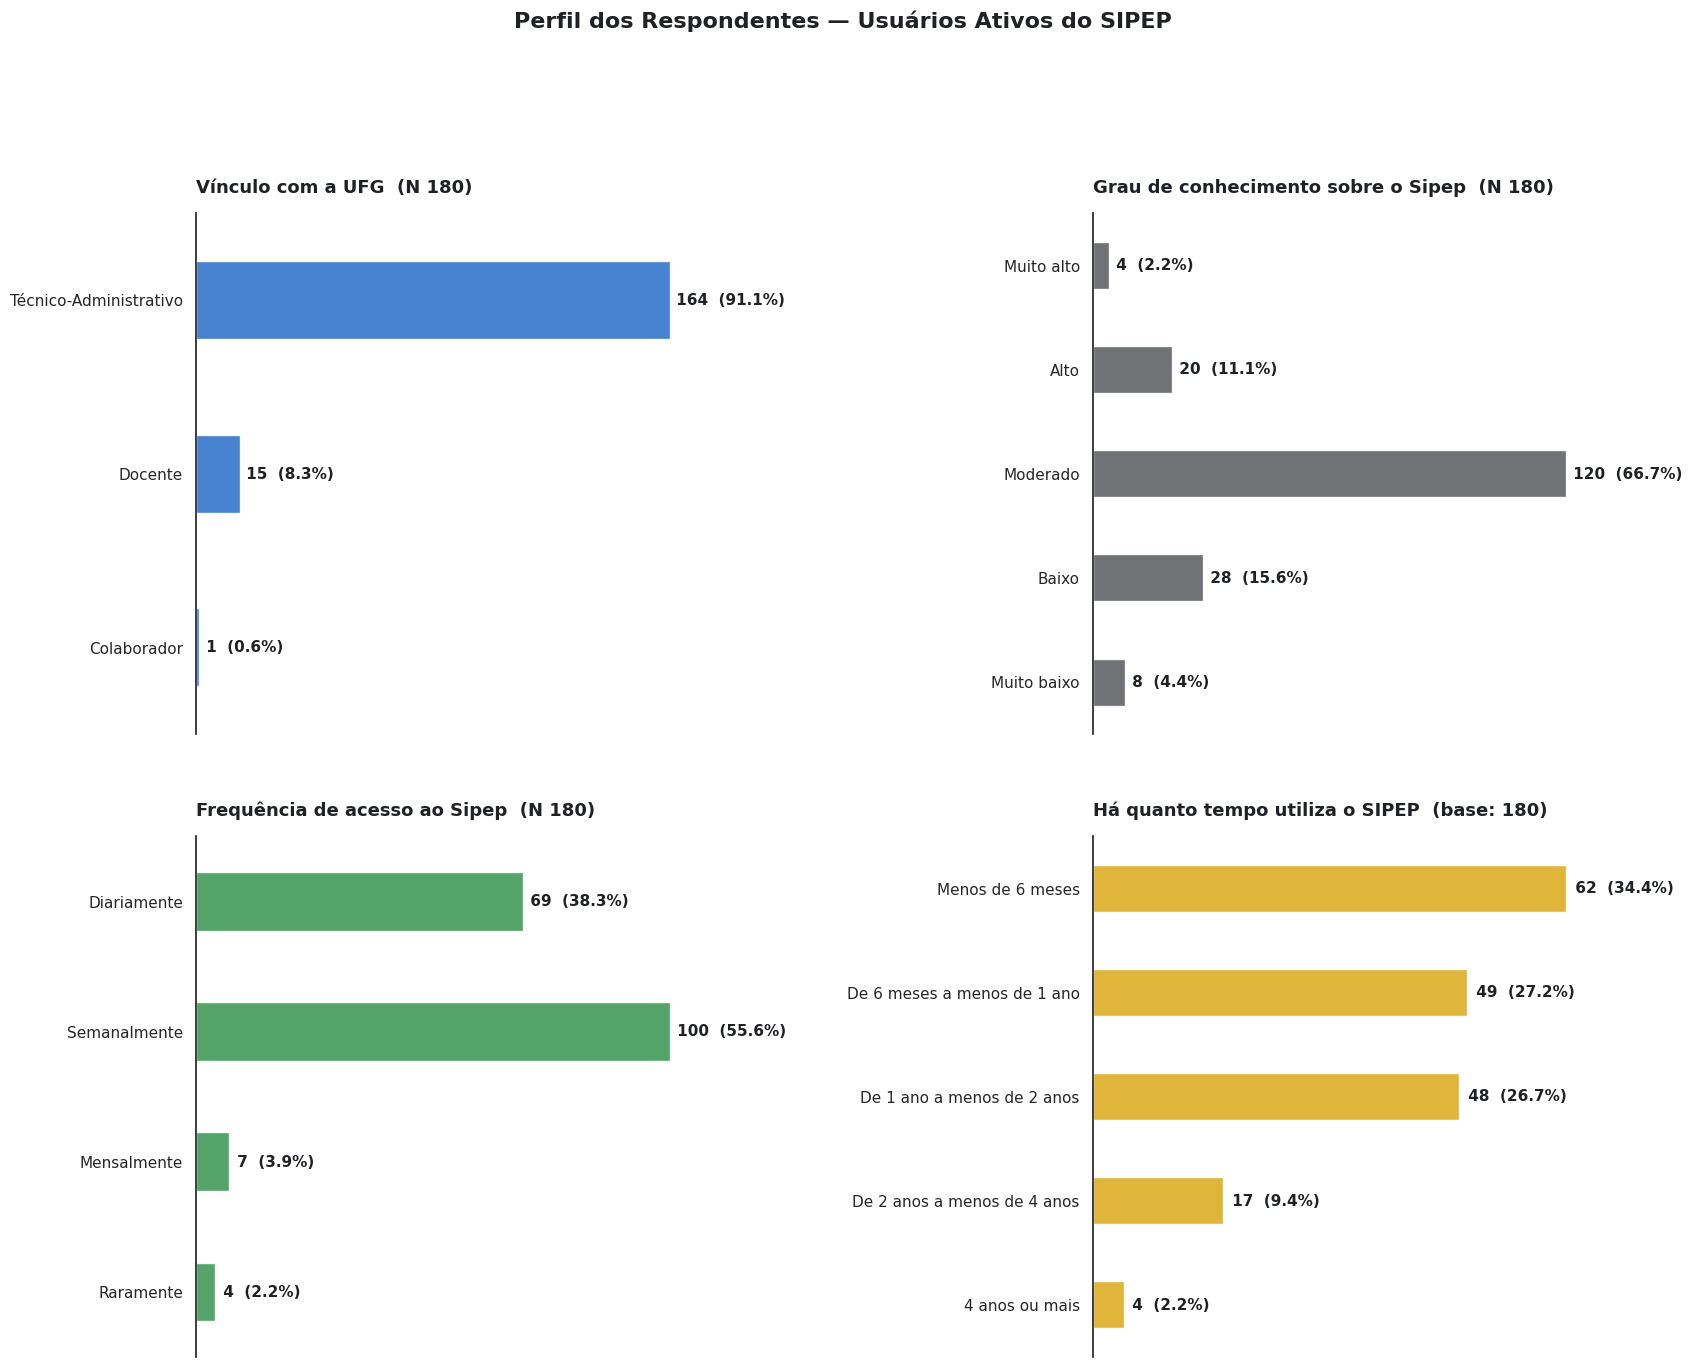


Resumo do perfil:
  • Técnicos-Administrativos representam 91.1% da amostra.
  • 66.7% classificam seu conhecimento como 'Moderado' — o nível mais frequente.
  • A maioria dos respondentes acessa o sistema semanalmente (55.6%).


In [46]:
#@title 📊 Seção 1 · Perfil dos respondentes { display-mode: "form" }
# --- Seção 1: Perfil dos respondentes ---
# Cada gráfico usa como base (denominador do %) apenas quem respondeu àquela pergunta.

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# (a) Vínculo com a UFG
vinculo, base_vinc = contagem_valida(df[COL['vinculo']])
sns.barplot(x=vinculo.values, y=vinculo.index, ax=axes[0,0],
            color=CORES['azul'], alpha=0.9, width=0.45)
rotular_barras(axes[0,0], base_vinc)
limpar_eixo(axes[0,0], f'Vínculo com a UFG  (N {base_vinc})')

# (b) Nível de conhecimento declarado
conhecimento, base_conh = contagem_valida(df[COL['conhecimento']], ordem=ORDEM_CONH)
sns.barplot(x=conhecimento.values, y=conhecimento.index, ax=axes[0,1],
            color=CORES['cinza'], alpha=0.9, width=0.45)
rotular_barras(axes[0,1], base_conh)
limpar_eixo(axes[0,1], f'Grau de conhecimento sobre o Sipep  (N {base_conh})')

# (c) Frequência de acesso
freq, base_freq = contagem_valida(df[COL['frequencia']], ordem=ORDEM_FREQ)
sns.barplot(x=freq.values, y=freq.index, ax=axes[1,0],
            color=CORES['verde'], alpha=0.9, width=0.45)
rotular_barras(axes[1,0], base_freq)
limpar_eixo(axes[1,0], f'Frequência de acesso ao Sipep  (N {base_freq})')

# (d) Tempo de uso
tempo, base_tempo = contagem_valida(df[COL['tempo']], ordem=ORDEM_TEMPO)
sns.barplot(x=tempo.values, y=tempo.index, ax=axes[1,1],
            color=CORES['amarelo'], alpha=0.9, width=0.45)
rotular_barras(axes[1,1], base_tempo)
limpar_eixo(axes[1,1], f'Há quanto tempo utiliza o SIPEP  (base: {base_tempo})')

fig.suptitle('Perfil dos Respondentes — Usuários Ativos do SIPEP',
             fontsize=16, fontweight='bold', color=CORES['texto'], y=1.01)
plt.tight_layout(pad=4.0)
plt.show()

# Resumo em texto
tae_pct = vinculo.get('Técnico-Administrativo', 0) / base_vinc * 100
moderado_pct = conhecimento.get('Moderado', 0) / base_conh * 100
freq_top = freq.sort_values(ascending=False)
print(f"\nResumo do perfil:")
print(f"  • Técnicos-Administrativos representam {tae_pct:.1f}% da amostra.")
print(f"  • {moderado_pct:.1f}% classificam seu conhecimento como 'Moderado' — o nível mais frequente.")
print(f"  • A maioria dos respondentes acessa o sistema {freq_top.index[0].lower()} ({freq_top.iloc[0]/base_freq*100:.1f}%).")

---
## 2. Usabilidade e Satisfação

Dois pontos centrais da pesquisa: os usuários consideram a navegação do sistema clara e intuitiva? E qual é o grau de satisfação geral com o SIPEP?

O cruzamento dessas duas variáveis permite identificar se problemas de interface estão associados à insatisfação.

In [1]:
#@title 📊 Seção 2 · Usabilidade e satisfação { display-mode: "form" }
# --- Seção 2: Usabilidade e satisfação ---
# Atenção metodológica: estas perguntas tiveram respostas em branco (navegação: 3, satisfação: 5).
# Os percentuais abaixo usam como base apenas quem respondeu, não os 180 da amostra.

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# (a) Percepção sobre a navegação
nav, base_nav = contagem_valida(df[COL['navegacao']], ordem=ORDEM_NAV)
sns.barplot(x=nav.values, y=nav.index, ax=axes[0],
            color=CORES['azul'], alpha=0.9, width=0.45)
rotular_barras(axes[0], base_nav)
limpar_eixo(axes[0], f'"A navegação no sistema é clara e intuitiva"  (base: {base_nav})')

# (b) Satisfação geral
sat, base_sat = contagem_valida(df[COL['satisfacao']], ordem=ORDEM_SAT)
sns.barplot(x=sat.values, y=sat.index, ax=axes[1],
            color=CORES['verde'], alpha=0.9, width=0.45)
rotular_barras(axes[1], base_sat)
limpar_eixo(axes[1], f'Satisfação geral com o SIPEP  (base: {base_sat})')

plt.tight_layout(pad=5.0)
plt.show()

# Cruzamento: Navegação × Satisfação
print("\n" + "─" * 80)
print("Cruzamento: Percepção de navegação × Satisfação geral")
print("─" * 80)

ct = pd.crosstab(df[COL['navegacao']], df[COL['satisfacao']])
ct = ct.reindex(index=ORDEM_NAV, columns=ORDEM_SAT).fillna(0).astype(int)

# Gráfico de barras empilhadas
fig2, ax2 = plt.subplots(figsize=(15, 7))
cores_sat = [CORES['verde'], CORES['azul'], '#9aa0a6', '#f2994a', CORES['vermelho']]
ct.plot(kind='barh', stacked=True, ax=ax2, color=cores_sat, alpha=0.95, width=0.5)


# Indicadores numéricos (base = quem respondeu cada pergunta)
satisfeitos = sat.get('Satisfeito', 0) + sat.get('Muito satisfeito', 0)
insatisfeitos = sat.get('Insatisfeito', 0) + sat.get('Muito insatisfeito', 0)
concordam_nav = nav.get('Concordo', 0) + nav.get('Concordo totalmente', 0)
discordam_nav = nav.get('Discordo', 0) + nav.get('Discordo totalmente', 0)

print(f"\nIndicadores principais:")
print(f"  • {satisfeitos/base_sat*100:.1f}% estão satisfeitos ou muito satisfeitos com o sistema.")
print(f"  • {insatisfeitos/base_sat*100:.1f}% estão insatisfeitos ou muito insatisfeitos.")
print(f"  • {concordam_nav/base_nav*100:.1f}% concordam que a navegação é clara e intuitiva.")
print(f"  • {discordam_nav/base_nav*100:.1f}% discordam — consideram a navegação confusa.")

NameError: name 'plt' is not defined

---
### 2.1 Métricas e teste estatístico de satisfação

Além das distribuições, vale resumir a satisfação em **indicadores objetivos** e testar se a relação entre usabilidade e satisfação é estatisticamente real (e não acaso amostral):

- **Score médio (escala 1–5)** com intervalo de confiança de 95% — sintetiza a satisfação em um único número comparável entre segmentos.
- **CSAT (Top-2-box)** — proporção de "Satisfeito" + "Muito satisfeito", métrica padrão de pesquisas de satisfação; e o **Bottom-2-box** (detratores).
- **Teste qui-quadrado** de independência entre *percepção de navegação* e *satisfação*, com o **V de Cramér** medindo a força da associação.

---
## Painel Interativo de Exploração (Dashboard)

Para permitir uma análise ágil, dinâmica e sob demanda, este painel permite realizar o cruzamento de variáveis-chave da pesquisa em tempo real.

Você pode filtrar a amostra por:
1. **Vínculo institucional** com a UFG
2. **Tempo de uso** declarado do SIPEP
3. **Nível de satisfação** geral

Ao alterar os filtros, os principais indicadores (KPIs) de satisfação e as visualizações de usabilidade/melhorias correspondentes ao segmento são recomputados imediatamente.

> [!TIP]
> **Nota sobre execução no Colab:** É necessário executar a célula de carregamento (Célula 1) e todas as células de visualização anteriores pelo menos uma vez para inicializar os dados e as funções gráficas auxiliares antes de interagir com o painel.

In [49]:
#@title 🎯 Painel interativo de exploração (Dashboard) { display-mode: "form" }
# --- Painel Interativo de Exploração (Dashboard) ---
# Metodologia Aplicada: Separação em camadas de Visualização (Quantitativa vs Qualitativa)
# e controles de estado gerenciados para evitar duplicação de dados em tela.
# Os KPIs usam como base apenas quem respondeu cada pergunta (ignorando brancos) — ver função contagem_valida.

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import textwrap

# 1. Componentes de UI (Filtros)
estilo = {'description_width': 'initial'}
layout = widgets.Layout(width='95%', margin='0 10px 10px 0')

opcoes_foco = ['📊 Visão Quantitativa: Geral', '⚙️ Visão Quantitativa: Usabilidade', '💡 Visão Quantitativa: Melhorias', '🏫 Visão Quantitativa: Capacitação', '📝 Visão Qualitativa: Feedback Aberto']

widget_foco = widgets.Dropdown(options=opcoes_foco, description='Foco Analítico:', style=estilo, layout=layout)
widget_vinculo = widgets.Dropdown(options=['Todos'] + list(df[COL['vinculo']].dropna().unique()), description='Vínculo:', style=estilo, layout=layout)
widget_tempo = widgets.Dropdown(options=['Todos'] + list(df[COL['tempo']].dropna().unique()), description='Tempo de Uso:', style=estilo, layout=layout)
widget_sat = widgets.Dropdown(options=['Todos'] + list(df[COL['satisfacao']].dropna().unique()), description='Satisfação:', style=estilo, layout=layout)
widget_freq = widgets.Dropdown(options=['Todos'] + list(df[COL['frequencia']].dropna().unique()), description='Frequência:', style=estilo, layout=layout)

# 2. Layout do Painel de Controle
header_html = widgets.HTML(value="""
<div style="background: linear-gradient(135deg, #1a73e8 0%, #1557b0 100%); padding: 20px; border-radius: 10px 10px 0 0; color: white; margin-bottom: 15px; font-family: sans-serif;">
    <h2 style="margin: 0 0 10px 0; font-size: 24px; color: white;">🎯 Dashboard Analítico Inteligente (SIPEP)</h2>
    <p style="margin: 0; font-size: 14px; opacity: 0.9;">Filtre a base de dados em tempo real e explore métricas <b>Quantitativas</b> e percepções <b>Qualitativas</b> (Engenharia de Requisitos).</p>
</div>
""")

linha1 = widgets.HBox([widget_foco, widget_vinculo], layout=widgets.Layout(width='100%'))
linha2 = widgets.HBox([widget_tempo, widget_sat, widget_freq], layout=widgets.Layout(width='100%'))
ui_filtros = widgets.VBox([header_html, linha1, linha2], layout=widgets.Layout(padding='15px', border='1px solid #e0e0e0', border_radius='10px', background_color='#f8f9fa', margin='0 0 20px 0'))

output_area = widgets.Output()

# 3. Lógica de Processamento e Visualização (Controller)
def atualizar_painel(change=None):
    # a. Obter valores atuais
    foco = widget_foco.value
    vinculo = widget_vinculo.value
    tempo = widget_tempo.value
    sat = widget_sat.value
    freq = widget_freq.value

    # b. Filtragem de Dados
    df_filtrado = df.copy()
    if vinculo != 'Todos': df_filtrado = df_filtrado[df_filtrado[COL['vinculo']] == vinculo]
    if tempo != 'Todos':   df_filtrado = df_filtrado[df_filtrado[COL['tempo']] == tempo]
    if sat != 'Todos':     df_filtrado = df_filtrado[df_filtrado[COL['satisfacao']] == sat]
    if freq != 'Todos':    df_filtrado = df_filtrado[df_filtrado[COL['frequencia']] == freq]

    n_atual = len(df_filtrado)

    with output_area:
        clear_output(wait=True)

        if n_atual == 0:
            display(HTML("<div style='padding:30px; text-align:center; color:#ea4335; font-size:16px; font-weight:bold;'>Nenhum respondente atende aos filtros selecionados.</div>"))
            return

        # c. Renderizar KPIs Globais
        # Cada KPI usa como base quem efetivamente respondeu a pergunta (ignora brancos),
        # evitando subestimar indicadores como o de capacitação (101 brancos na amostra cheia).
        base_sat = df_filtrado[COL['satisfacao']].notna().sum()
        base_nav = df_filtrado[COL['navegacao']].notna().sum()
        base_cap = df_filtrado[COL['capacitacao']].notna().sum()

        sat_pos = df_filtrado[COL['satisfacao']].isin(['Satisfeito', 'Muito satisfeito']).sum()
        nav_pos = df_filtrado[COL['navegacao']].isin(['Concordo', 'Concordo totalmente']).sum()
        cap_sim = df_filtrado[COL['capacitacao']].isin(['Sim']).sum()

        sat_pct = (sat_pos / base_sat * 100) if base_sat > 0 else 0
        nav_pct = (nav_pos / base_nav * 100) if base_nav > 0 else 0
        cap_pct = (cap_sim / base_cap * 100) if base_cap > 0 else 0

        kpis_html = f"""
        <div style="display: flex; gap: 20px; margin-bottom: 25px; font-family: sans-serif;">
            <div style="flex: 1; background: #fff; padding: 20px; border-radius: 8px; border-left: 5px solid #1a73e8; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
                <div style="font-size: 14px; color: #5f6368; text-transform: uppercase; letter-spacing: 0.5px;">Amostra Filtrada</div>
                <div style="font-size: 32px; font-weight: bold; color: #202124; margin: 5px 0;">{n_atual}</div>
                <div style="font-size: 12px; color: #5f6368;">respondentes no segmento</div>
            </div>
            <div style="flex: 1; background: #fff; padding: 20px; border-radius: 8px; border-left: 5px solid #34a853; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
                <div style="font-size: 14px; color: #5f6368; text-transform: uppercase; letter-spacing: 0.5px;">Alta Satisfação</div>
                <div style="font-size: 32px; font-weight: bold; color: #202124; margin: 5px 0;">{sat_pct:.0f}%</div>
                <div style="font-size: 12px; color: #5f6368;">Satisfeito ou Muito Satisfeito <span style="color:#9aa0a6;">(base {base_sat})</span></div>
            </div>
            <div style="flex: 1; background: #fff; padding: 20px; border-radius: 8px; border-left: 5px solid #fbbc05; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
                <div style="font-size: 14px; color: #5f6368; text-transform: uppercase; letter-spacing: 0.5px;">Boa Usabilidade</div>
                <div style="font-size: 32px; font-weight: bold; color: #202124; margin: 5px 0;">{nav_pct:.0f}%</div>
                <div style="font-size: 12px; color: #5f6368;">Acha o sistema intuitivo <span style="color:#9aa0a6;">(base {base_nav})</span></div>
            </div>
            <div style="flex: 1; background: #fff; padding: 20px; border-radius: 8px; border-left: 5px solid #ea4335; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
                <div style="font-size: 14px; color: #5f6368; text-transform: uppercase; letter-spacing: 0.5px;">Déficit Capacitação</div>
                <div style="font-size: 32px; font-weight: bold; color: #202124; margin: 5px 0;">{cap_pct:.0f}%</div>
                <div style="font-size: 12px; color: #5f6368;">Demandam treinamento <span style="color:#9aa0a6;">(base {base_cap})</span></div>
            </div>
        </div>
        """
        display(HTML(kpis_html))

        # d. Roteamento de Visualização (Foco Analítico)
        if foco == '📊 Visão Quantitativa: Geral':
            fig, axes = plt.subplots(1, 2, figsize=(18, 7))
            vc, base_vc = contagem_valida(df_filtrado[COL['vinculo']])
            sns.barplot(x=vc.values, y=vc.index, ax=axes[0], color=CORES['azul'], alpha=0.9, width=0.45)
            rotular_barras(axes[0], base_vc)
            limpar_eixo(axes[0], 'Distribuição de Vínculos')

            tc, base_tc = contagem_valida(df_filtrado[COL['tempo']], ordem=ORDEM_TEMPO)
            sns.barplot(x=tc.values, y=tc.index, ax=axes[1], color=CORES['cinza'], alpha=0.9, width=0.45)
            rotular_barras(axes[1], base_tc)
            limpar_eixo(axes[1], 'Tempo de Experiência')
            plt.tight_layout(pad=3.0); plt.show(); plt.close('all')

        elif foco == '⚙️ Visão Quantitativa: Usabilidade':
            fig, axes = plt.subplots(1, 2, figsize=(18, 7))
            nav, base_nav_g = contagem_valida(df_filtrado[COL['navegacao']], ordem=ORDEM_NAV)
            sns.barplot(x=nav.values, y=nav.index, ax=axes[0], color=CORES['amarelo'], alpha=0.9, width=0.45)
            rotular_barras(axes[0], base_nav_g)
            limpar_eixo(axes[0], 'Clareza e Navegação Intuitiva')

            satc, base_sat_g = contagem_valida(df_filtrado[COL['satisfacao']], ordem=ORDEM_SAT)
            sns.barplot(x=satc.values, y=satc.index, ax=axes[1], color=CORES['verde'], alpha=0.9, width=0.45)
            rotular_barras(axes[1], base_sat_g)
            limpar_eixo(axes[1], 'Satisfação Geral')
            plt.tight_layout(pad=3.0); plt.show(); plt.close('all')

        elif foco == '💡 Visão Quantitativa: Melhorias':
            fig, axes = plt.subplots(1, 2, figsize=(18, 7))
            # Melhorias Q7 (Apenas as principais)
            opcoes = df_filtrado[COL['melhoria']].dropna().str.split(', ').explode()
            if len(opcoes) > 0:
                c = opcoes.value_counts().head(6)
                sns.barplot(x=c.values, y=c.index, ax=axes[0], color=CORES['vermelho'], alpha=0.9, width=0.45)
                for bar in axes[0].patches:
                    if bar.get_width() > 0: axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, f" {int(bar.get_width())}", va='center', fontweight='bold', color=CORES['texto'])
                limpar_eixo(axes[0], 'O que contribuiria para aumentar o uso? (Top 6)')
            else:
                axes[0].text(0.5, 0.5, 'Sem dados', ha='center', va='center'); limpar_eixo(axes[0], 'Melhorias')

            # Módulos mais usados
            uso = df_filtrado[COL['uso']].dropna().str.split(', ').explode().value_counts().head(6)
            if len(uso) > 0:
                sns.barplot(x=uso.values, y=uso.index, ax=axes[1], color=CORES['azul'], alpha=0.9, width=0.45)
                for bar in axes[1].patches:
                    if bar.get_width() > 0: axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, f" {int(bar.get_width())}", va='center', fontweight='bold', color=CORES['texto'])
                limpar_eixo(axes[1], 'Módulos Mais Utilizados')
            else:
                axes[1].text(0.5, 0.5, 'Sem dados', ha='center', va='center'); limpar_eixo(axes[1], 'Uso')
            plt.tight_layout(pad=3.0); plt.show(); plt.close('all')

        elif foco == '🏫 Visão Quantitativa: Capacitação':
            fig, axes = plt.subplots(1, 2, figsize=(18, 7))
            cc, base_cc = contagem_valida(df_filtrado[COL['capacitacao']])
            sns.barplot(x=cc.values, y=cc.index, ax=axes[0], color=CORES['roxo'], alpha=0.9, width=0.4)
            rotular_barras(axes[0], base_cc)
            limpar_eixo(axes[0], f'Demanda por Capacitação (base: {base_cc} respostas)')

            cq = df_filtrado[COL['cap_quais']].dropna().str.split(', ').explode().value_counts().head(6)
            if len(cq) > 0:
                sns.barplot(x=cq.values, y=cq.index, ax=axes[1], color=CORES['vermelho'], alpha=0.9, width=0.45)
                for bar in axes[1].patches:
                    if bar.get_width() > 0: axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, f" {int(bar.get_width())}", va='center', fontweight='bold', color=CORES['texto'])
                limpar_eixo(axes[1], 'Módulos com Maior Demanda de Treinamento')
            else:
                axes[1].text(0.5, 0.5, 'Sem dados', ha='center', va='center'); limpar_eixo(axes[1], 'Treinamento')
            plt.tight_layout(pad=3.0); plt.show(); plt.close('all')

        elif foco == '📝 Visão Qualitativa: Feedback Aberto':
            # Engenharia de Requisitos: Extração de Feedback Livre
            sugestoes = df_filtrado[COL['sugestoes']].dropna()

            # Html builder
            qual_html = "<div style='font-family: sans-serif; background: white; padding: 20px; border-radius: 8px; border: 1px solid #e0e0e0;'>"
            qual_html += "<h3 style='margin-top:0; color: #1a73e8; border-bottom: 2px solid #1a73e8; padding-bottom: 5px;'>💬 Amostra de Sugestões e Comentários Abertos</h3>"

            if len(sugestoes) == 0:
                qual_html += "<p style='color: #5f6368; font-style: italic;'>Nenhum comentário aberto registrado por este grupo.</p>"
            else:
                qual_html += f"<p style='color: #5f6368; font-size: 13px; margin-bottom: 20px;'>{len(sugestoes)} respondentes neste segmento deixaram sugestões textuais. Abaixo estão até 10 relatos recentes:</p>"
                qual_html += "<ul style='padding-left: 20px;'>"

                # Exibir até 10 comentários qualitativos aleatórios ou os primeiros
                for i, text in enumerate(sugestoes.head(10)):
                    qual_html += f"<li style='margin-bottom: 12px; line-height: 1.5; color: #202124; background: #f8f9fa; padding: 10px; border-radius: 5px; border-left: 3px solid #fbbc05;'>\"{text}\"</li>"

                qual_html += "</ul>"

            qual_html += "</div>"
            display(HTML(qual_html))

# 4. Registrar Eventos
widget_foco.observe(atualizar_painel, names='value')
widget_vinculo.observe(atualizar_painel, names='value')
widget_tempo.observe(atualizar_painel, names='value')
widget_sat.observe(atualizar_painel, names='value')
widget_freq.observe(atualizar_painel, names='value')

# 5. Renderização Master
# Agrupando tudo num único VBox evita o "bug" de replicação do output na interface do Colab.
painel_completo = widgets.VBox([ui_filtros, output_area])

# Primeiro preenchemos o output_area simulando o estado inicial (None)
atualizar_painel(None)

# Depois exibimos o container master unificado (UMA ÚNICA VEZ)
display(painel_completo)


---
## 3. Demandas e Melhorias

O que os usuários pedem para usar mais o SIPEP? Esta seção mostra:
- Quais módulos do sistema são mais utilizados
- Quais ações os usuários consideram que aumentariam sua frequência de uso
- Em quais módulos há maior demanda por capacitação

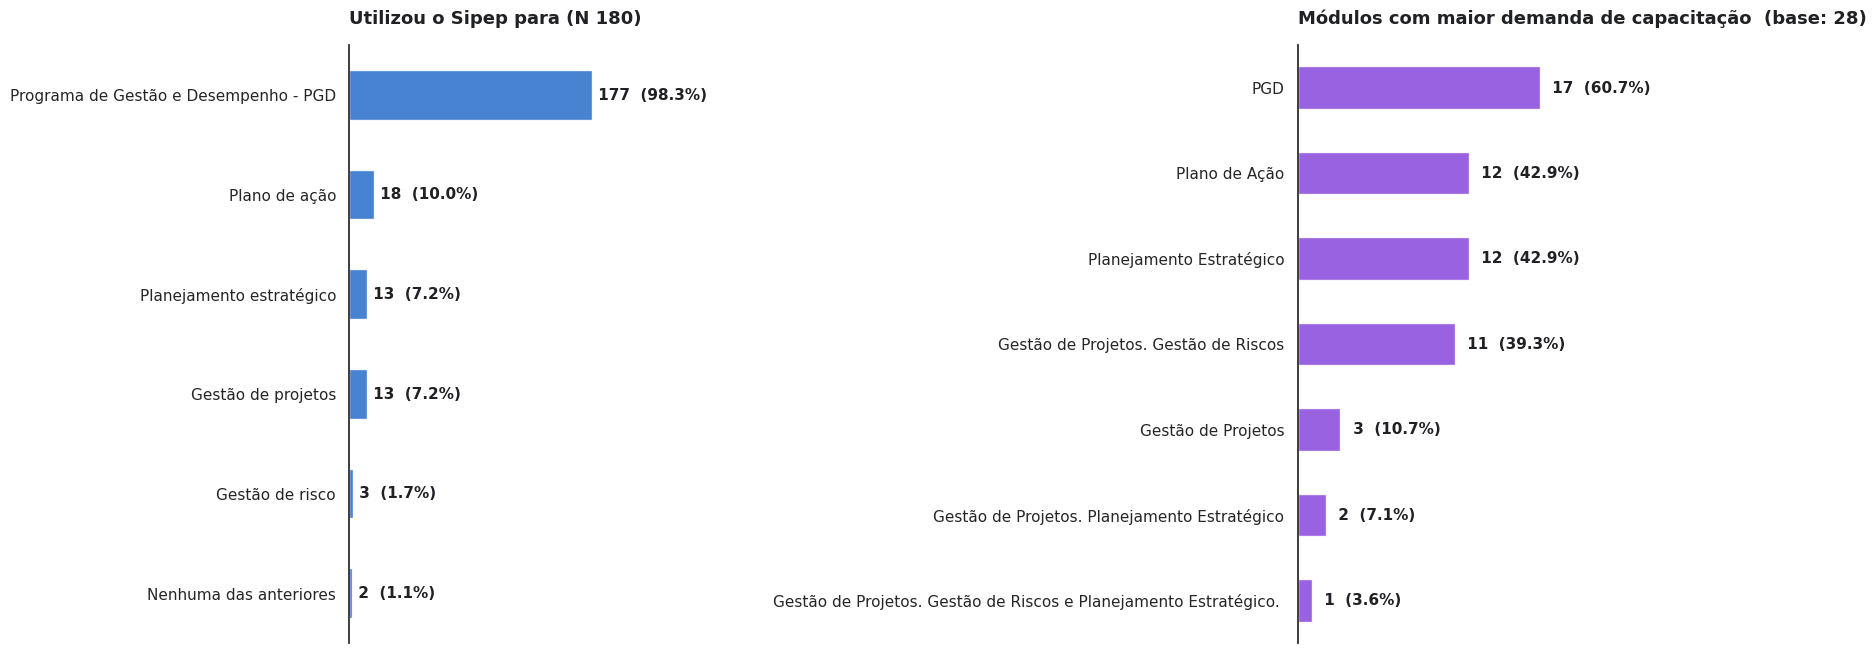


Resumo:
  • O módulo mais utilizado é 'Programa de Gestão e Desempenho - PGD' (177 menções, 98.3% de quem respondeu a Q6).
  • Capacitação (Q17A): 41 de 79 que responderam declararam necessidade = 51.9%.
    (Atenção: 101 pessoas não responderam a Q17A — por isso a base é 79, não 180.)
  • Módulo com maior demanda de capacitação: 'PGD' (17 menções).


In [50]:
#@title 📊 Seção 3 · Módulos e necessidade de capacitação { display-mode: "form" }
# --- Seção 3: Módulos mais utilizados e necessidade de capacitação ---

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# (a) Módulos mais utilizados (Q6 é múltipla escolha — base = quem respondeu a Q6)
base_uso = df[COL['uso']].notna().sum()
dados_uso = df[COL['uso']].dropna().str.split(', ').explode().value_counts()
sns.barplot(x=dados_uso.values, y=dados_uso.index, ax=axes[0],
            color=CORES['azul'], alpha=0.9, width=0.5)
rotular_barras(axes[0], base_uso)
limpar_eixo(axes[0], f'Utilizou o Sipep para (N {base_uso})')

# (b) Demanda de capacitação por módulo (Q17B — base = quem respondeu a Q17B)
base_cap_quais = df[COL['cap_quais']].notna().sum()
cap_modulos = df[COL['cap_quais']].dropna().str.split(', ').explode().value_counts()

if len(cap_modulos) > 0:
    sns.barplot(x=cap_modulos.values, y=cap_modulos.index, ax=axes[1],
                color=CORES['roxo'], alpha=0.9, width=0.5)
    rotular_barras(axes[1], base_cap_quais)
limpar_eixo(axes[1], f'Módulos com maior demanda de capacitação  (base: {base_cap_quais})')

plt.tight_layout(pad=5.0)
plt.show()

# Capacitação (Q17A) — base = quem respondeu, não os 180 da amostra.
# 101 pessoas deixaram em branco; usar o total subestimaria muito o indicador.
cap_contagem, base_cap = contagem_valida(df[COL['capacitacao']])
precisa_cap = int(cap_contagem.get('Sim', 0))

print(f"\nResumo:")
print(f"  • O módulo mais utilizado é '{dados_uso.index[0]}' ({dados_uso.iloc[0]} menções, "
      f"{dados_uso.iloc[0]/base_uso*100:.1f}% de quem respondeu a Q6).")
print(f"  • Capacitação (Q17A): {precisa_cap} de {base_cap} que responderam declararam necessidade "
      f"= {precisa_cap/base_cap*100:.1f}%.")
print(f"    (Atenção: {N - base_cap} pessoas não responderam a Q17A — por isso a base é {base_cap}, não {N}.)")
if len(cap_modulos) > 0:
    print(f"  • Módulo com maior demanda de capacitação: '{cap_modulos.index[0]}' ({cap_modulos.iloc[0]} menções).")

---
### 3.1 Análise detalhada: O que aumentaria a frequência de uso do SIPEP

A pergunta 7 do formulário — *"Quais opções poderiam contribuir para aumentar a sua frequência de uso do Sipep?"* — permitia múltiplas respostas. É a pergunta que concentra a maior variedade de dados, então merece uma exploração mais aprofundada.

Os gráficos a seguir mostram:
1. **Ranking geral** das opções mais citadas
2. **Agrupamento por categoria** — visão consolidada das demandas
3. **Cruzamento com vínculo** — o que Técnicos-Administrativos pedem vs. Docentes
4. **Cruzamento com satisfação** — o que os insatisfeitos pedem de diferente

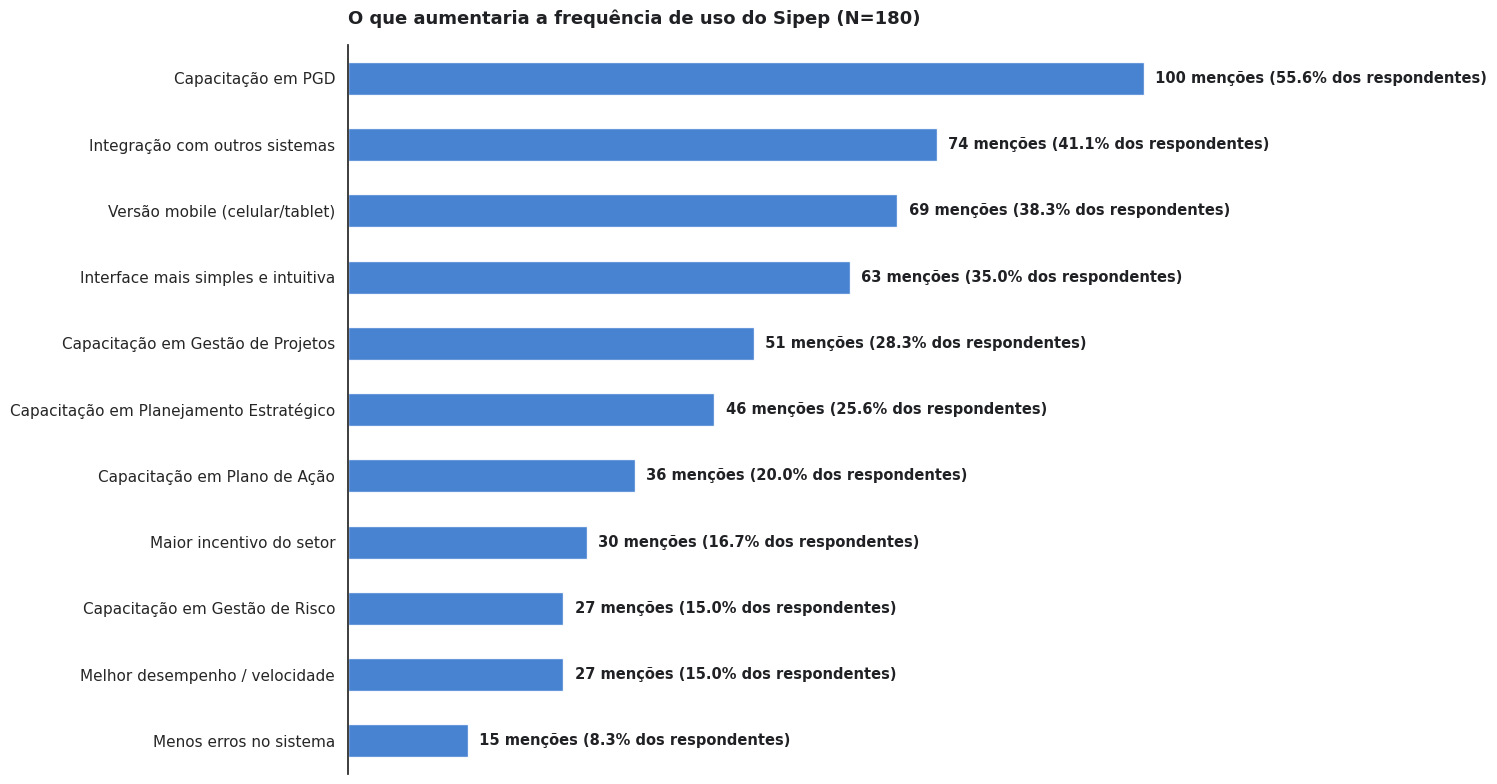


180 dos 180 usuários responderam esta pergunta.
Total de 561 marcações (média de 3.1 opções por respondente).


In [51]:
#@title 📊 Seção 3.1 · Ranking geral de melhorias (Q7) { display-mode: "form" }
# --- Q7: Ranking geral das opções mais citadas ---

opcoes_melhoria = df[COL['melhoria']].dropna().str.split(', ').explode()
contagem = opcoes_melhoria.value_counts()
total_respondentes_q7 = df[COL['melhoria']].dropna().shape[0]

# Encurtar os rótulos muito longos para o gráfico ficar legível
rotulos_curtos = {
    'Mais conhecimento sobre Programa de Gestão e Desempenho - PGD': 'Capacitação em PGD',
    'Mais conhecimento sobre gestão de projetos': 'Capacitação em Gestão de Projetos',
    'Mais conhecimento sobre planejamento estratégico': 'Capacitação em Planejamento Estratégico',
    'Mais conhecimento sobre plano de ação': 'Capacitação em Plano de Ação',
    'Mais conhecimento sobre gestão de risco': 'Capacitação em Gestão de Risco',
    'Maior integração do Sipep com outros sistemas institucionais': 'Integração com outros sistemas',
    'Possibilidade de utilizar o sistema em dispositivos móveis (celular ou tablet)': 'Versão mobile (celular/tablet)',
    'Interface do sistema mais simples e intuitiva': 'Interface mais simples e intuitiva',
    'Melhor desempenho do sistema (maior rapidez no carregamento)': 'Melhor desempenho / velocidade',
    'Maior incentivo da unidade ou setor para utilização do sistema': 'Maior incentivo do setor',
    'Menor ocorrência de erros no sistema': 'Menos erros no sistema',
    'Maior divulgação sobre as possibilidades de uso.': 'Maior divulgação das funcionalidades',
    'Fluxos mais claros sobre os procedimentos': 'Fluxos mais claros',
    'FAQ e Tutoriais.': 'FAQ e Tutoriais',
    'Melhoria em Recurso de Acessibilidade.': 'Melhorias de acessibilidade',
}

# Aplicar rótulos curtos
contagem_limpa = contagem.copy()
contagem_limpa.index = [rotulos_curtos.get(x, x) for x in contagem_limpa.index]

# Filtrar apenas itens com 5+ menções para evitar poluição
contagem_filtrada = contagem_limpa[contagem_limpa >= 5]

fig, ax = plt.subplots(figsize=(15, 8))
sns.barplot(x=contagem_filtrada.values, y=contagem_filtrada.index, ax=ax,
            color=CORES['azul'], alpha=0.9, width=0.5)

for bar in ax.patches:
    w = bar.get_width()
    if w > 0:
        pct = w / total_respondentes_q7 * 100
        ax.text(w + 0.8, bar.get_y() + bar.get_height()/2,
                f" {int(w)} menções ({pct:.1f}% dos respondentes)",
                va='center', fontweight='bold', color=CORES['texto'], fontsize=10.5)

limpar_eixo(ax, f'O que aumentaria a frequência de uso do Sipep (N={total_respondentes_q7})')
ax.tick_params(axis='y', labelsize=11)
plt.tight_layout()
plt.show()

print(f"\n{total_respondentes_q7} dos {N} usuários responderam esta pergunta.")
print(f"Total de {int(contagem.sum())} marcações (média de {contagem.sum()/total_respondentes_q7:.1f} opções por respondente).")

---
## 5. Respostas Abertas — Sugestões e Críticas por Módulo

As perguntas 9 a 13 e 15 do formulário eram campos abertos, onde os usuários puderam escrever livremente o que poderia ser melhorado em cada módulo do SIPEP.

Abaixo, os comentários são listados por módulo, filtrados para remover respostas vazias ou genéricas (como "nada", "não sei", "n/a").

In [54]:
#@title 💬 Seção 5 · Respostas abertas por módulo { display-mode: "form" }
# --- Seção 5: Respostas abertas por módulo ---

# Lista de respostas que serão ignoradas (não acrescentam informação)
RESPOSTAS_VAZIAS = {
    'não', 'nada', 'não utilizo', 'n/a', 'ok', 'atende',
    'sem sugestões', 'não uso', 'não se aplica',
    'não tenho opinião formada.', 'sem opinião formada no momento',
    'não utilizo esta ferramenta.', 'não tenho uma opinião formada.',
    'não sei', '-', '.', 'nao'
}

modulos = {
    'Plano de Ação':                          COL['plano_acao'],
    'Gestão de Projetos':                     COL['projetos'],
    'Planejamento Estratégico':               COL['planej'],
    'Gestão de Riscos':                       COL['riscos'],
    'Programa de Gestão e Desempenho (PGD)':  COL['pgd'],
    'Sugestões gerais sobre o sistema':       COL['sugestoes'],
}

# Cores de borda para cada card
cores_borda = [CORES['azul'], CORES['vermelho'], CORES['amarelo'],
               CORES['verde'], CORES['roxo'], '#00acc1']

for idx, (titulo, coluna) in enumerate(modulos.items()):
    # Filtrar respostas válidas
    comentarios = []
    for texto in df[coluna].dropna():
        t = str(texto).strip()
        if t.lower() not in RESPOSTAS_VAZIAS and len(t) > 2:
            if t not in comentarios:
                comentarios.append(t)

    borda = cores_borda[idx % len(cores_borda)]

    # Montar HTML do card
    html = f'''
    <div style="font-family: sans-serif; margin-bottom: 20px;
                border: 1px solid #dadce0; border-left: 5px solid {borda};
                border-radius: 8px; overflow: hidden;">
        <div style="background: #f8f9fa; padding: 12px 16px; font-weight: bold;
                    color: #202124; font-size: 14px; border-bottom: 1px solid #dadce0;">
            {titulo}
            <span style="float: right; color: #5f6368; font-weight: normal; font-size: 12px;">
                {len(comentarios)} comentário(s) relevante(s)
            </span>
        </div>
        <div style="padding: 14px 16px; background: #fff; max-height: 300px; overflow-y: auto;">
    '''

    if comentarios:
        for c in comentarios:
            html += f'<p style="margin: 0 0 10px 0; padding-bottom: 10px; border-bottom: 1px dashed #f1f3f4; color: #202124; font-size: 13px; line-height: 1.5;">"<i>{c}</i>"</p>'
    else:
        html += '<p style="margin: 0; color: #9aa0a6; font-size: 13px; font-style: italic;">Nenhum comentário registrado para este módulo.</p>'

    html += '</div></div>'
    display(HTML(html))

# Contagem total de comentários únicos
total_comentarios = 0
for coluna in modulos.values():
    for texto in df[coluna].dropna():
        t = str(texto).strip()
        if t.lower() not in RESPOSTAS_VAZIAS and len(t) > 2:
            total_comentarios += 1

print(f"\nTotal de comentários relevantes registrados: {total_comentarios}")
print(f"(Considerando todas as perguntas abertas, incluindo repetições entre módulos)")


Total de comentários relevantes registrados: 306
(Considerando todas as perguntas abertas, incluindo repetições entre módulos)
